In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# my function to process air quality data 
def AQI_VIS(CountyName, yr):
    
    # read the data
    pth ='https://aqs.epa.gov/aqsweb/airdata/daily_88101_'+str(yr)+'.zip'
    pm25_daily= pd.read_csv(pth, parse_dates=['Date Local'])
    
    # make a short list
    pm25_daily_short = pm25_daily[['Site Num', 'Date Local', 'State Name', 'County Name','AQI']]
    
    # extract AQI for selected county 
    AQI = pm25_daily_short.loc[pm25_daily['County Name']== CountyName]
    
    # use pd.pivot_table to move up site num to columns 
    AQI_flattened = pd.DataFrame(AQI.pivot_table(index=['Date Local', 'State Name', 'County Name'],
                        columns='Site Num', values='AQI').reset_index() )
    
    # plot annual AQI 
    plt.figure(figsize=(15,5), dpi=80)
    plt.plot(AQI_flattened.iloc[:,0], AQI_flattened.iloc[:,3])
    plt.plot(AQI_flattened.iloc[:,0], AQI_flattened.iloc[:,4])
    
    #return AQI_flattened  
    

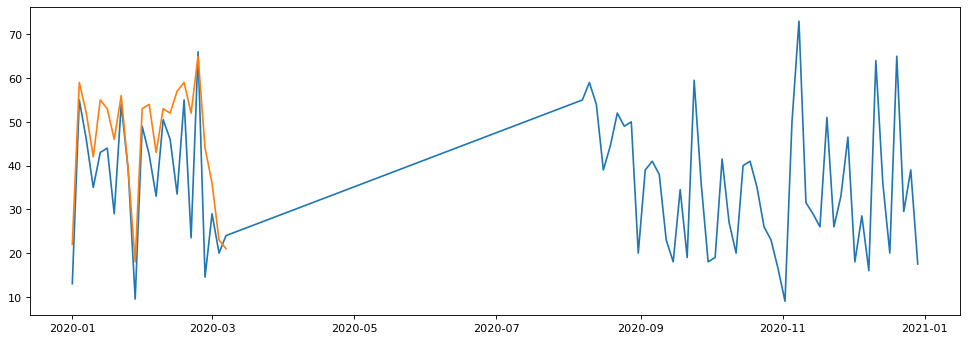

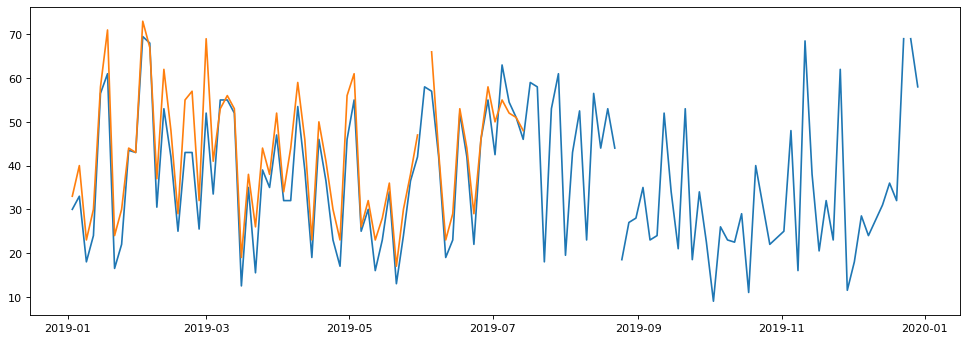

In [4]:
AQI_VIS('New York', 2020)
AQI_VIS('New York', 2019)

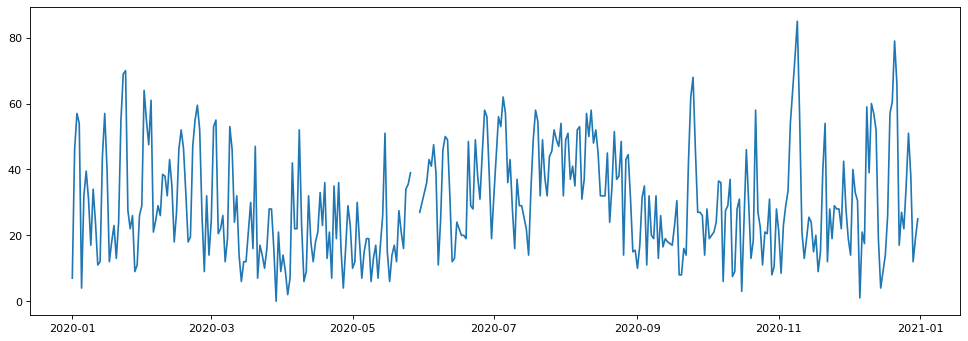

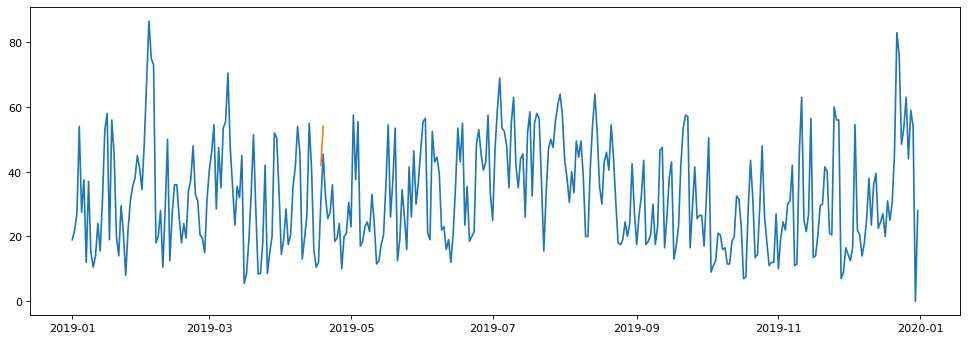

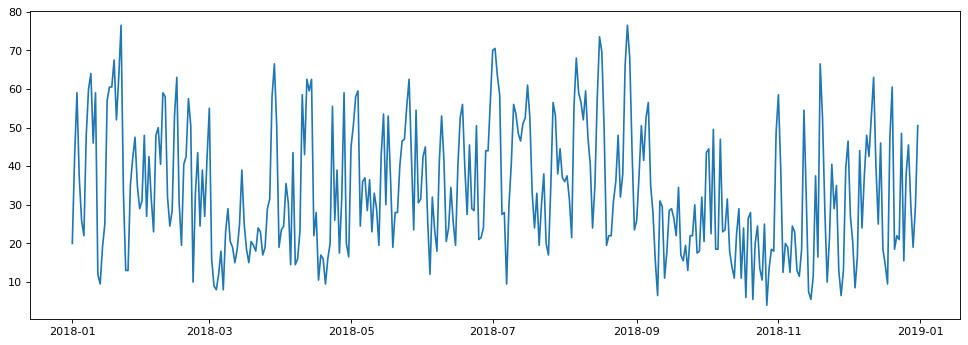

In [5]:
AQI_VIS('Queens', 2020)
AQI_VIS('Queens', 2019)
AQI_VIS('Queens', 2018)
